In [1]:
!wget https://raw.githubusercontent.com/lukeolson/cs556-demos/refs/heads/main/cg.py

--2026-09-23 17:08:00--  https://raw.githubusercontent.com/lukeolson/cs556-demos/refs/heads/main/cg.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2831 (2.8K) [text/plain]
Saving to: ‘cg.py’

cg.py               100%[===================>]   2.76K  --.-KB/s    in 0s      

2026-09-23 17:08:00 (32.3 MB/s) - ‘cg.py’ saved [2831/2831]



In [2]:
import numpy as np
import scipy.sparse as sparse
import matplotlib.pyplot as plt
from cg import cg

In [3]:
n = 1000
d = 0.5 + np.sqrt(np.arange(1, n + 1))
A = sparse.diags([np.ones(n - 100),
                  np.ones(n - 1),
                  d,
                  np.ones(n - 1),
                  np.ones(n - 100)],
                 [-100, -1, 0, 1, 100], format='csr')
b = np.ones(n)

In [11]:
res = []
x, _ = cg(A, b, tol=1e-16, maxiter=40, residuals=res)

#### Task 1:
Run CG with a diagonal preconditioner.

In [19]:
res_precond = []
D_inv_half = sparse.diags(1 / np.sqrt(d))
x_precond, _ = cg(D_inv_half @ A @ D_inv_half, D_inv_half @ b, tol=1e-16, maxiter=40, residuals=res_precond)
x_precond = D_inv_half @ x_precond

In [20]:
print(np.linalg.norm(x - x_precond))

1.0943909815553437e-05


#### Task 2:
Compare the residuals.

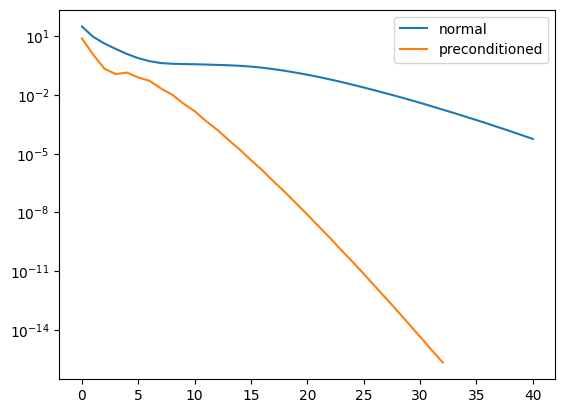

In [10]:
fig, ax = plt.subplots()
ax.semilogy(res, label="normal")
ax.semilogy(res_precond, label="preconditioned")
ax.legend()